In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from micrograd.engine import Value
from micrograd.nn import Neuron, Layer, MLP

In [3]:
np.random.seed(1337)
random.seed(1337)

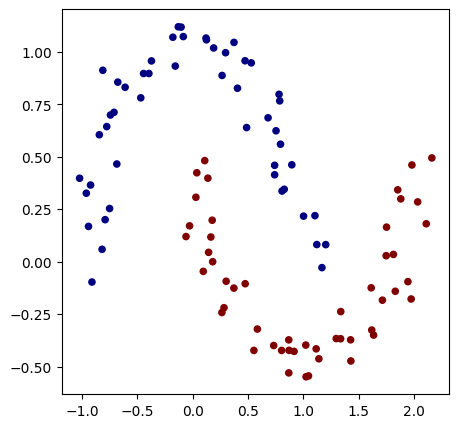

In [4]:
# make up a dataset

from sklearn.datasets import make_moons, make_blobs
X, y = make_moons(n_samples=100, noise=0.1)

y = y*2 - 1 # make y be -1 or 1
# visualize in 2D
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')

### EML model — same `make_moons` data, complex-valued weights

The EML (Exp-Minus-Log) operator is `eml(x, y) = exp(x) − ln(y)`.
Because `ln(y)` is real-undefined for `y ≤ 0`, we let weights and intermediate
activations be **complex** — the principal-branch complex `log` is well-defined
everywhere except `0` — and bridge back to real with `.real()` at the network
head so the existing SVM-margin loss still works unchanged.

Gradient descent on complex weights follows the standard real-loss-of-complex-
parameters convention: each parameter's `grad` is `∂L/∂Re(p) + i·∂L/∂Im(p)`,
and the update is `p ← p − lr·grad` (no conjugate — the conjugates already live
inside the backward rules of `*`, `**`, `exp`, `log`, `eml`).

In [5]:
from micrograd.nn import EMLMLP

eml_model = EMLMLP(2, [4, 4, 1])
print(eml_model)
print("number of parameters", len(eml_model.parameters()))

EMLMLP of [Layer 'eml_l0' of [EMLNeuron(2), EMLNeuron(2), EMLNeuron(2), EMLNeuron(2)], Layer 'eml_l1' of [EMLNeuron(4), EMLNeuron(4), EMLNeuron(4), EMLNeuron(4)], Layer 'eml_l2' of [EMLNeuron(4)]]
number of parameters 74


In [6]:
# Same SVM max-margin loss as above, but evaluated against eml_model.
# eml_model returns a real-valued Value (via .real() at the head), so this
# is a verbatim copy of the original loss() with `model` -> `eml_model`.

def eml_loss(batch_size=None):
    if batch_size is None:
        Xb, yb = X, y
    else:
        ri = np.random.permutation(X.shape[0])[:batch_size]
        Xb, yb = X[ri], y[ri]
    inputs = [list(map(Value, xrow)) for xrow in Xb]
    scores = list(map(eml_model, inputs))

    losses = [(1 + -yi*si).relu() for yi, si in zip(yb, scores)]
    data_loss = sum(losses) * (1.0 / len(losses))
    alpha = 1e-4
    # |p|^2 keeps the regularizer real even with complex p.
    reg_loss = alpha * sum(((p * Value(p.data.conjugate())).real() for p in eml_model.parameters()))
    total_loss = data_loss + reg_loss

    accuracy = [(yi > 0) == (si.data > 0) for yi, si in zip(yb, scores)]
    return total_loss, sum(accuracy) / len(accuracy)

tl, ta = eml_loss()
print(tl, ta)

+:(data=1.81585, grad=0.00000) 0.52


In [7]:
# Complex-Adam: m is complex (carries direction), v is real (carries |g|^2),
# so sqrt(v_hat) is well-defined and the update direction stays complex.

steps = 1000
num_features = len(eml_model.parameters())
params    = np.zeros(num_features, dtype=np.complex128)
gradients = np.zeros(num_features, dtype=np.complex128)
m = np.zeros(num_features, dtype=np.complex128)
v = np.zeros(num_features, dtype=np.float64)

def complex_adam(params, gradients, m, v, t,
                 learning_rate=0.005, beta1=0.9, beta2=0.999, epsilon=1e-8):
    m = beta1 * m + (1 - beta1) * gradients
    v = beta2 * v + (1 - beta2) * (gradients * gradients.conj()).real
    m_hat = m / (1 - beta1 ** t)
    v_hat = v / (1 - beta2 ** t)
    params = params - learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)
    return params, m, v

eml_losses = []
eml_accs = []
for k in range(steps):
    total_loss, acc = eml_loss()
    eml_model.zero_grad()
    total_loss.backward()

    ps = eml_model.parameters()
    for i in range(len(ps)):
        params[i]    = ps[i].data if isinstance(ps[i].data, complex) else complex(ps[i].data, 0.)
        gradients[i] = ps[i].grad if isinstance(ps[i].grad, complex) else complex(ps[i].grad, 0.)

    params, m, v = complex_adam(params, gradients, m, v, k + 1)

    for i in range(len(ps)):
        ps[i].data = complex(params[i])

    eml_losses.append(total_loss.data)
    eml_accs.append(acc)

    if acc >= 1.0:
        print(f"step {k}: converged — loss {total_loss.data:.4f}, acc {acc:.2%}")
        break

    if k % 25 == 0:
        max_abs_grad = max(abs(p.grad) for p in eml_model.parameters())
        print(f"step {k}: loss {total_loss.data:.4f}, acc {acc:.2%}, max|grad| {max_abs_grad:.4f}")

step 0: loss 1.8159, acc 52.00%, max|grad| 33.8117
step 25: loss 0.5320, acc 83.00%, max|grad| 1.7804
step 50: loss 0.3207, acc 90.00%, max|grad| 1.0446
step 75: loss 0.2089, acc 95.00%, max|grad| 0.9466
step 100: loss 0.1574, acc 98.00%, max|grad| 0.5003
step 125: loss 0.1240, acc 98.00%, max|grad| 0.5066
step 150: loss 0.1045, acc 98.00%, max|grad| 0.1620
step 175: loss 0.0875, acc 98.00%, max|grad| 0.4891
step 200: loss 0.0663, acc 99.00%, max|grad| 0.5943
step 219: converged — loss 0.0435, acc 100.00%


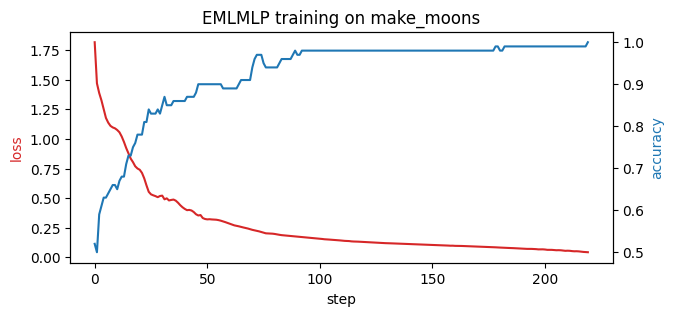

In [8]:
# Loss / accuracy curves.
fig, ax1 = plt.subplots(figsize=(7, 3))
ax1.plot(eml_losses, color='tab:red', label='loss')
ax1.set_xlabel('step'); ax1.set_ylabel('loss', color='tab:red')
ax2 = ax1.twinx()
ax2.plot(eml_accs, color='tab:blue', label='acc')
ax2.set_ylabel('accuracy', color='tab:blue')
plt.title('EMLMLP training on make_moons')
plt.show()

In [9]:
# Decision boundary of the EML model on the same make_moons data.

h = 0.05
x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.7
y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.7
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(eml_model, inputs))
Z = np.array([s.data > 0 for s in scores]).reshape(xx.shape)

plt.figure(figsize=(5, 5))
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max()); plt.ylim(yy.min(), yy.max())
plt.title('EMLMLP decision boundary')
plt.show()

OverflowError: math range error

In [ ]:
# Inspect a learned complex weight — should be genuinely off the real axis.
p = eml_model.parameters()[0]
print(p, '->', p.data)